In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torchaudio

# ── paths ──────────────────────────────────────────────────────────────────
# Use the FULL extracted audio so transcript timestamps (in original space)
# align exactly — audio_for_asr.wav is trimmed and would be 13s off.
AUDIO_PATH      = "data/reports/session_005/01_ingest/audio_extracted.wav"
TRANSCRIPT_PATH = "data/reports/session_005/02_asr/transcript.txt"
CONVO_START_S   = 13.0   # from inventory.json → first 13s are pre-conversation silence

# ── load audio ─────────────────────────────────────────────────────────────
waveform, sr = torchaudio.load(AUDIO_PATH)
if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)
audio = waveform.squeeze().numpy()
total_s = len(audio) / sr
print(f"Audio: {total_s:.1f}s  @ {sr} Hz  ({len(audio):,} samples)")

# ── RMS envelope (20ms frames, 10ms hop) ──────────────────────────────────
def rms_envelope(signal, sr, frame_s=0.02, hop_s=0.01):
    frame = int(frame_s * sr)
    hop   = int(hop_s  * sr)
    n_frames = (len(signal) - frame) // hop
    frames = np.lib.stride_tricks.sliding_window_view(signal, frame)[::hop][:n_frames]
    energy = np.sqrt((frames ** 2).mean(axis=1))
    times  = np.arange(n_frames) * hop / sr
    return times, energy

t_rms, env = rms_envelope(audio, sr)

# ── parse transcript → (start, end, speaker) ──────────────────────────────
COLORS = {"ARZT": "#2196F3", "BEGLEITUNG": "#F44336", "UNKNOWN": "#888888"}

def parse_ts(ts):
    m, s = ts.split(":")
    return int(m) * 60 + int(s)

turns = []
with open(TRANSCRIPT_PATH, encoding="utf-8") as fh:
    for line in fh:
        hit = re.match(r'\[(\d+:\d+)\s*→\s*(\d+:\d+)\]\s+(\w+):', line)
        if hit:
            turns.append((parse_ts(hit.group(1)), parse_ts(hit.group(2)), hit.group(3)))

print(f"{len(turns)} turns: "
      f"ARZT={sum(1 for _,_,s in turns if s=='ARZT')}, "
      f"BEGLEITUNG={sum(1 for _,_,s in turns if s=='BEGLEITUNG')}")

def draw_spans(ax, turn_list, alpha=0.30):
    for start, end, spk in turn_list:
        ax.axvspan(start, end, color=COLORS.get(spk, "#888"), alpha=alpha, linewidth=0)

legend_patches = [mpatches.Patch(color=c, alpha=0.6, label=lbl)
                  for lbl, c in COLORS.items() if lbl != "UNKNOWN"]

# ── figure: 3 rows ─────────────────────────────────────────────────────────
ZOOM_S, ZOOM_E = CONVO_START_S, CONVO_START_S + 120   # first 2 min of conversation

fig, axes = plt.subplots(3, 1, figsize=(22, 11),
                         gridspec_kw={"height_ratios": [1, 2, 2], "hspace": 0.18})

# ── row 0: RMS envelope — full recording ───────────────────────────────────
ax0 = axes[0]
ax0.fill_between(t_rms, env, color="#444", alpha=0.75, linewidth=0)
ax0.set_ylabel("RMS", fontsize=9)
ax0.set_xlim(0, total_s)
ax0.set_ylim(0)
ax0.set_title("Session 005  |  RMS envelope + speaker turns (full recording)", fontsize=11)
draw_spans(ax0, turns, alpha=0.35)
# mark the zoom window
ax0.axvspan(ZOOM_S, ZOOM_E, color="gold", alpha=0.12, linewidth=0)
ax0.axvline(ZOOM_S, color="goldenrod", lw=1.2, ls="--")
ax0.axvline(ZOOM_E, color="goldenrod", lw=1.2, ls="--")

# ── row 1: full-recording spectrogram ──────────────────────────────────────
ax1 = axes[1]
ax1.specgram(audio, Fs=sr, NFFT=1024, noverlap=896,
             cmap="magma", scale="dB", vmin=-70, vmax=-10)
ax1.set_ylabel("Frequency (Hz)", fontsize=9)
ax1.set_ylim(0, 4000)
ax1.set_xlim(0, total_s)
ax1.set_title("Spectrogram — full recording (magma, 0–4 kHz)", fontsize=10)
draw_spans(ax1, turns, alpha=0.25)

# ── row 2: zoomed spectrogram — first 2 min of conversation ────────────────
zs, ze = int(ZOOM_S * sr), int(ZOOM_E * sr)
audio_zoom = audio[zs:ze]
zoom_dur = ZOOM_E - ZOOM_S

ax2 = axes[2]
ax2.specgram(audio_zoom, Fs=sr, NFFT=512, noverlap=480,
             cmap="magma", scale="dB", vmin=-70, vmax=-10)
ax2.set_ylabel("Frequency (Hz)", fontsize=9)
ax2.set_xlabel("Time (s, original timeline)", fontsize=9)
ax2.set_ylim(0, 4000)
ax2.set_xlim(0, zoom_dur)
ax2.set_title(f"Zoom: {int(ZOOM_S)}s – {int(ZOOM_E)}s  (first 2 min of conversation)", fontsize=10)

# re-label x-axis in original time
tick_step = 15  # every 15s
ticks = np.arange(0, zoom_dur + 1, tick_step)
ax2.set_xticks(ticks)
ax2.set_xticklabels([f"{int(ZOOM_S + t)}" for t in ticks])

# draw spans clipped to zoom window (in zoom-relative coords)
turns_zoom = [(max(s - ZOOM_S, 0), min(e - ZOOM_S, zoom_dur), spk)
              for s, e, spk in turns if e > ZOOM_S and s < ZOOM_E]
draw_spans(ax2, turns_zoom, alpha=0.35)
ax2.legend(handles=legend_patches, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("session_005_audio_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → session_005_audio_features.png")


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# ── figure ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.08)

colors = ["#2196F3", "#F44336"]   # blue = speaker 1, red = speaker 2
labels = ["Speaker 1", "Speaker 2"]
audios = [a1, a2]

# Row 0 — waveforms
for col, (audio, c, lbl) in enumerate(zip(audios, colors, labels)):
    ax = fig.add_subplot(gs[0, col])
    ax.plot(t, audio, color=c, linewidth=0.4, alpha=0.8)
    ax.set_title(f"{lbl} — waveform", fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(t[0], t[-1])

# Row 1 — spectrograms
for col, (audio, c, lbl) in enumerate(zip(audios, colors, labels)):
    ax = fig.add_subplot(gs[1, col])
    ax.specgram(audio, Fs=sr, NFFT=512, noverlap=384,
                cmap="magma", scale="dB", vmin=-80)
    ax.set_title(f"{lbl} — spectrogram", fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_ylim(0, 4000)   # voice range

# Row 2 — overlaid speaking activity
ax = fig.add_subplot(gs[2, :])
ax.fill_between(t_rms, e1, alpha=0.55, color=colors[0], label=labels[0])
ax.fill_between(t_rms, e2, alpha=0.55, color=colors[1], label=labels[1])
ax.set_title("Speaking activity (RMS energy over time)", fontsize=11)
ax.set_xlabel("Time (s)")
ax.set_ylabel("RMS")
ax.set_xlim(t_rms[0], t_rms[-1])
ax.legend(loc="upper right")

plt.suptitle("SepFormer output — two separated speaker tracks", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


NameError: name 'a1' is not defined

<Figure size 1800x1000 with 0 Axes>

Estimated horizon Y: 0.42028985507246375


(np.float64(-0.5), np.float64(670.5), np.float64(344.5), np.float64(-0.5))

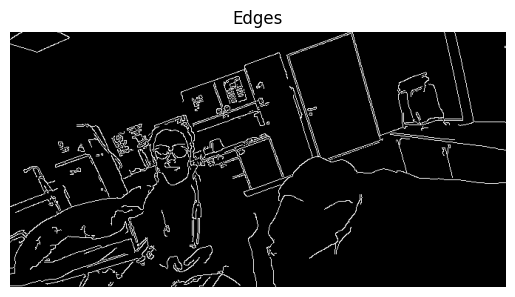

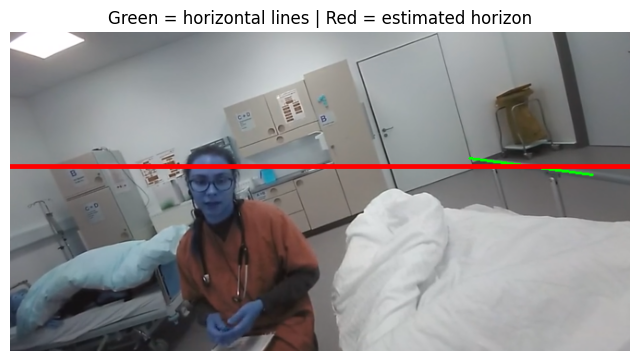

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("room.png")

plt.imshow(img)
plt.axis("off")
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

edges = cv2.Canny(gray, 50, 150)

plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=100,
    maxLineGap=10
)

h, w = img.shape[:2]

y_values = []
weights = []
horizontal_lines = []

for line in lines:
    x1, y1, x2, y2 = line[0]
    
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
    
    if abs(angle) < 10:  # near horizontal
        
        y_mid = (y1 + y2) / 2
        Y = y_mid / h
        
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        
        y_values.append(Y)
        weights.append(length)
        horizontal_lines.append((x1,y1,x2,y2))

horizon_y = np.median(y_values)

print("Estimated horizon Y:", horizon_y)


vis = img.copy()

for x1,y1,x2,y2 in horizontal_lines:
    cv2.line(vis,(x1,y1),(x2,y2),(0,255,0),2)

horizon_pixel = int(horizon_y * h)

cv2.line(vis,(0,horizon_pixel),(w,horizon_pixel),(255,0,0),3)

plt.figure(figsize=(8,6))
plt.imshow(vis)
plt.title("Green = horizontal lines | Red = estimated horizon")
plt.axis("off")

(np.float64(-0.5), np.float64(670.5), np.float64(344.5), np.float64(-0.5))

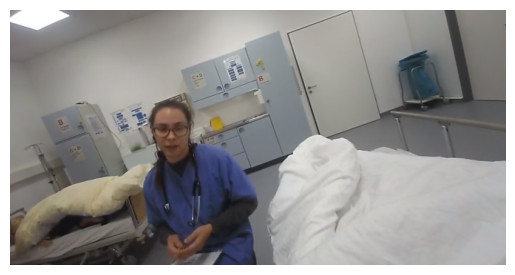

In [6]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("room.png")

if img is None:
    raise ValueError("Image not found. Check the file path.")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [4]:
import os
print(os.listdir())

['test.ipynb', 'DATA_SPEC.md', '.git', 'PIPELINE.md', 'templates', 'pipeline.py', 'environment.yml', 'utils', 'config', '.gitignore', 'README.md', 'stages', 'data', 'CLAUDE.md', 'llama-cpp-python', 'room.png', 'tasks', 'test_separation.py']
